<a href="https://colab.research.google.com/github/Maniacravi/pytorch-deep-learning/blob/main/02_pytorch_classification_mani.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PyTorch NN Classification

## What we're going to cover

In this notebook we're going to reiterate over the PyTorch workflow we covered in [01. PyTorch Workflow](https://www.learnpytorch.io/02_pytorch_classification/).

<img src="https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/images/01_a_pytorch_workflow.png" alt="a pytorch workflow flowchart" width=900/>

Except instead of trying to predict a straight line (predicting a number, also called a regression problem), we'll be working on a **classification problem**.

Specifically, we're going to cover:

| **Topic** | **Contents** |
| ----- | ----- |
| **0. Architecture of a classification neural network** | Neural networks can come in almost any shape or size, but they typically follow a similar floor plan. |
| **1. Getting binary classification data ready** | Data can be almost anything but to get started we're going to create a simple binary classification dataset. |
| **2. Building a PyTorch classification model** | Here we'll create a model to learn patterns in the data, we'll also choose a **loss function**, **optimizer** and build a **training loop** specific to classification. |
| **3. Fitting the model to data (training)** | We've got data and a model, now let's let the model (try to) find patterns in the (**training**) data. |
| **4. Making predictions and evaluating a model (inference)** | Our model's found patterns in the data, let's compare its findings to the actual (**testing**) data. |
| **5. Improving a model (from a model perspective)** | We've trained and evaluated a model but it's not working, let's try a few things to improve it. |
| **6. Non-linearity** | So far our model has only had the ability to model straight lines, what about non-linear (non-straight) lines? |
| **7. Replicating non-linear functions** | We used **non-linear functions** to help model non-linear data, but what do these look like? |
| **8. Putting it all together with multi-class classification** | Let's put everything we've done so far for binary classification together with a multi-class classification problem. |


## 0. Architecture of a classification neural network

Before we get into writing code, let's look at the general architecture of a classification neural network.

| **Hyperparameter** | **Binary Classification** | **Multiclass classification** |
| --- | --- | --- |
| **Input layer shape** (`in_features`) | Same as number of features (e.g. 5 for age, sex, height, weight, smoking status in heart disease prediction) | Same as binary classification |
| **Hidden layer(s)** | Problem specific, minimum = 1, maximum = unlimited | Same as binary classification |
| **Neurons per hidden layer** | Problem specific, generally 10 to 512 | Same as binary classification |
| **Output layer shape** (`out_features`) | 1 (one class or the other) | 1 per class (e.g. 3 for food, person or dog photo) |
| **Hidden layer activation** | Usually [ReLU](https://pytorch.org/docs/stable/generated/torch.nn.ReLU.html#torch.nn.ReLU) (rectified linear unit) but [can be many others](https://en.wikipedia.org/wiki/Activation_function#Table_of_activation_functions) | Same as binary classification |
| **Output activation** | [Sigmoid](https://en.wikipedia.org/wiki/Sigmoid_function) ([`torch.sigmoid`](https://pytorch.org/docs/stable/generated/torch.sigmoid.html) in PyTorch)| [Softmax](https://en.wikipedia.org/wiki/Softmax_function) ([`torch.softmax`](https://pytorch.org/docs/stable/generated/torch.nn.Softmax.html) in PyTorch) |
| **Loss function** | [Binary crossentropy](https://en.wikipedia.org/wiki/Cross_entropy#Cross-entropy_loss_function_and_logistic_regression) ([`torch.nn.BCELoss`](https://pytorch.org/docs/stable/generated/torch.nn.BCELoss.html) in PyTorch) | Cross entropy ([`torch.nn.CrossEntropyLoss`](https://pytorch.org/docs/stable/generated/torch.nn.CrossEntropyLoss.html) in PyTorch) |
| **Optimizer** | [SGD](https://pytorch.org/docs/stable/generated/torch.optim.SGD.html) (stochastic gradient descent), [Adam](https://pytorch.org/docs/stable/generated/torch.optim.Adam.html) (see [`torch.optim`](https://pytorch.org/docs/stable/optim.html) for more options) | Same as binary classification |

Of course, this ingredient list of classification neural network components will vary depending on the problem you're working on.

But it's more than enough to get started.

We're going to get hands-on with this setup throughout this notebook.

## 1. Make the data and get it ready

In [1]:
from sklearn.datasets import make_circles

n_samples = 1000

X, y = make_circles(n_samples,
                    noise=0.03,
                    random_state=42)

X.shape, y.shape

((1000, 2), (1000,))

In [2]:
# Make a pandas df

import pandas as pd

circles = pd.DataFrame({"X1": X[:, 0],
                        "X2": X[:, 1],
                        "label": y})
circles.head(10)

,X1,X2,label
0,0.754246,0.231481,1
1,-0.756159,0.153259,1
2,-0.815392,0.173282,1
3,-0.393731,0.692883,1
4,0.442208,-0.896723,0
5,-0.479646,0.676435,1
6,-0.013648,0.803349,1
7,0.771513,0.147760,1
8,-0.169322,-0.793456,1
9,-0.121486,1.021509,0


In [3]:
# count the labels

circles["label"].value_counts()

,count
label,
1,500
0,500


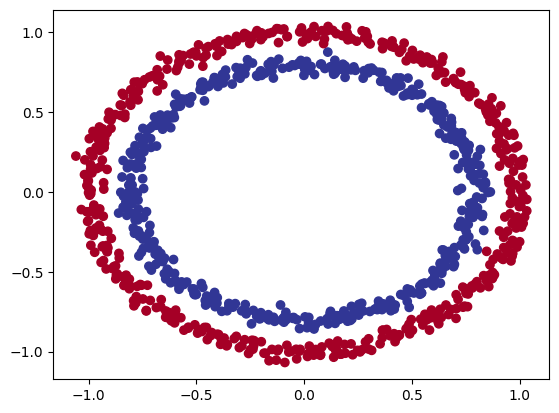

In [4]:
# Let's plot the data

import matplotlib.pyplot as plt

plt.scatter(x=X[:, 0],
            y=X[:, 1],
            c=y,
            cmap=plt.cm.RdYlBu)

plt.show()

Okay, our problem is to solve this. Develop a NN model that can effecively classify these two types of dots. This is called a **toy problem** (a problem that's used to try and test things out on) in ML

### Check input and output shapes

In [5]:
# Check X and y shape

X.shape, y.shape

((1000, 2), (1000,))

In [6]:
# View first example of each

print(f'First sample of X: {X[0]}; first sample of y: {y[0]}')
print(f'Second sample of X: {X[1]}; second sample of y: {y[1]}')

# Shapes of samples
print(f'Shape of X[0]: {X[0].shape}; shape of y[0]: {y[0].shape}')
print(f'Shape of X[1]: {X[1].shape}; shape of y[1]: {y[1].shape}')


First sample of X: [0.75424625 0.23148074]; first sample of y: 1
Second sample of X: [-0.75615888  0.15325888]; second sample of y: 1
Shape of X[0]: (2,); shape of y[0]: ()
Shape of X[1]: (2,); shape of y[1]: ()


### Turn data into tensors

In [7]:
import torch
torch.__version__

'2.6.0+cu124'

In [8]:
# Turn data into tensors

X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float) # two different ways to do the same thing

X[:5], y[:5]

(tensor([[ 0.7542,  0.2315],
         [-0.7562,  0.1533],
         [-0.8154,  0.1733],
         [-0.3937,  0.6929],
         [ 0.4422, -0.8967]]),
 tensor([1., 1., 1., 1., 0.]))

In [9]:
# check the datatypes
X.dtype, y.dtype

(torch.float32, torch.float32)

In [10]:
# Split the testset into train and test

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) # 0.2 indicates 20% = test data

len(X_train), len(X_test), len(y_train), len(y_test)

(800, 200, 800, 200)

## 2. Building a model


We'll break it down into a few parts.

1. Setting up device agnostic code (so our model can run on CPU or GPU if it's available).
2. Constructing a model by subclassing `nn.Module`.
3. Defining a loss function and optimizer.
4. Creating a training loop (this'll be in the next section).

In [11]:
import torch
from torch import nn

# create device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
device


'cuda'

Let's create a model class that:
1. Subclasses `nn.Module` (almost all PyTorch models are subclasses of `nn.Module`).
2. Creates 2 `nn.Linear` layers in the constructor capable of handling the input and output shapes of `X` and `y`.
3. Defines a `forward()` method containing the forward pass computation of the model.
4. Instantiates the model class and sends it to the target `device`.

In [12]:
X_train

tensor([[ 0.6579, -0.4651],
        [ 0.6319, -0.7347],
        [-1.0086, -0.1240],
        ...,
        [ 0.0157, -1.0300],
        [ 1.0110,  0.1680],
        [ 0.5578, -0.5709]])

In [13]:
# Construct the model
class CircleModelV0(nn.Module):
  def __init__(self):
    super().__init__()

    # Create nn.Linear layers
    self.layer_1 = nn.Linear(in_features=2, out_features=5) # 5 is the number of units in the hidden layer
    self.layer_2 = nn.Linear(in_features=5, out_features=1)

  # Deine the forward method
  def forward(self, x):
    return self.layer_2(self.layer_1(x))

# Instantiate the model and send it to the target device
model_0 = CircleModelV0().to(device)
model_0

CircleModelV0(
  (layer_1): Linear(in_features=2, out_features=5, bias=True)
  (layer_2): Linear(in_features=5, out_features=1, bias=True)
)

In [14]:
next(model_0.parameters()).device

device(type='cuda', index=0)

next(model_0.parameters()).device essentially grabs the first parameter of your model_0 and reports whether it's on the CPU or GPU (CUDA). This is a common way to verify that your model has been successfully moved to the desired device using .to(device).

In [15]:
# Let's create the same model using nn.Sequential

model_1 = nn.Sequential(
    nn.Linear(in_features=2, out_features=5),
    nn.Linear(in_features=5, out_features=1)
).to(device)

model_1

Sequential(
  (0): Linear(in_features=2, out_features=5, bias=True)
  (1): Linear(in_features=5, out_features=1, bias=True)
)

In [16]:
model_0.state_dict()

OrderedDict([('layer_1.weight',
              tensor([[ 0.3387,  0.6338],
                      [-0.6751, -0.4757],
                      [-0.1562,  0.4870],
                      [ 0.3930, -0.6869],
                      [-0.2004, -0.1554]], device='cuda:0')),
             ('layer_1.bias',
              tensor([ 0.4139,  0.3858,  0.6776, -0.1937,  0.1515], device='cuda:0')),
             ('layer_2.weight',
              tensor([[-0.0836, -0.2693,  0.0229, -0.1573, -0.4459]], device='cuda:0')),
             ('layer_2.bias', tensor([0.0722], device='cuda:0'))])

In [17]:
model_1.state_dict()

OrderedDict([('0.weight',
              tensor([[-0.1769, -0.3754],
                      [ 0.1967,  0.1193],
                      [-0.5975, -0.1305],
                      [ 0.6264,  0.1136],
                      [-0.1421,  0.2839]], device='cuda:0')),
             ('0.bias',
              tensor([ 0.0443, -0.6344,  0.2892, -0.5273,  0.4716], device='cuda:0')),
             ('1.weight',
              tensor([[0.1309, 0.1519, 0.2262, 0.1052, 0.3770]], device='cuda:0')),
             ('1.bias', tensor([0.1687], device='cuda:0'))])

These are all random values so making predictions with this would lead to terrible preds. Let's build a training loop

### 2.1 Setup loss function and optimizer

We've setup a loss (also called a criterion or cost function) and optimizer before in [notebook 01](https://www.learnpytorch.io/01_pytorch_workflow/#creating-a-loss-function-and-optimizer-in-pytorch).

But different problem types require different loss functions.

For example, for a regression problem (predicting a number) you might use mean absolute error (MAE) loss.

And for a binary classification problem (like ours), you'll often use [binary cross entropy](https://towardsdatascience.com/understanding-binary-cross-entropy-log-loss-a-visual-explanation-a3ac6025181a) as the loss function.

However, the same optimizer function can often be used across different problem spaces.

For example, the stochastic gradient descent optimizer (SGD, `torch.optim.SGD()`) can be used for a range of problems, and the same applies to the Adam optimizer (`torch.optim.Adam()`).

| Loss function/Optimizer | Problem type | PyTorch Code |
| ----- | ----- | ----- |
| Stochastic Gradient Descent (SGD) optimizer | Classification, regression, many others. | [`torch.optim.SGD()`](https://pytorch.org/docs/stable/generated/torch.optim.SGD.html) |
| Adam Optimizer | Classification, regression, many others. | [`torch.optim.Adam()`](https://pytorch.org/docs/stable/generated/torch.optim.Adam.html) |
| Binary cross entropy loss | Binary classification | [`torch.nn.BCELossWithLogits`](https://pytorch.org/docs/stable/generated/torch.nn.BCEWithLogitsLoss.html) or [`torch.nn.BCELoss`](https://pytorch.org/docs/stable/generated/torch.nn.BCELoss.html) |
| Cross entropy loss | Multi-class classification | [`torch.nn.CrossEntropyLoss`](https://pytorch.org/docs/stable/generated/torch.nn.CrossEntropyLoss.html) |
| Mean absolute error (MAE) or L1 Loss | Regression | [`torch.nn.L1Loss`](https://pytorch.org/docs/stable/generated/torch.nn.L1Loss.html) |
| Mean squared error (MSE) or L2 Loss | Regression | [`torch.nn.MSELoss`](https://pytorch.org/docs/stable/generated/torch.nn.MSELoss.html#torch.nn.MSELoss) |  

*Table of various loss functions and optimizers, there are more but these are some common ones you'll see.*

Since we're working with a binary classification problem, let's use a binary cross entropy loss function.

> **Note:** Recall a **loss function** is what measures how *wrong* your model predictions are, the higher the loss, the worse your model.
>
> Also, PyTorch documentation often refers to loss functions as "loss criterion" or "criterion", these are all different ways of describing the same thing.

PyTorch has two binary cross entropy implementations:
1. [`torch.nn.BCELoss()`](https://pytorch.org/docs/stable/generated/torch.nn.BCELoss.html) - Creates a loss function that measures the binary cross entropy between the target (label) and input (features).
2. [`torch.nn.BCEWithLogitsLoss()`](https://pytorch.org/docs/stable/generated/torch.nn.BCEWithLogitsLoss.html) - This is the same as above except it has a sigmoid layer ([`nn.Sigmoid`](https://pytorch.org/docs/stable/generated/torch.nn.Sigmoid.html)) built-in (we'll see what this means soon).

Which one should you use?

The [documentation for `torch.nn.BCEWithLogitsLoss()`](https://pytorch.org/docs/stable/generated/torch.nn.BCEWithLogitsLoss.html) states that it's more numerically stable than using `torch.nn.BCELoss()` after a `nn.Sigmoid` layer.

So generally, implementation 2 is a better option. However for advanced usage, you may want to separate the combination of `nn.Sigmoid` and `torch.nn.BCELoss()` but that is beyond the scope of this notebook.

Knowing this, let's create a loss function and an optimizer.

For the optimizer we'll use `torch.optim.SGD()` to optimize the model parameters with learning rate 0.1.

> **Note:** There's a [discussion on the PyTorch forums about the use of `nn.BCELoss` vs. `nn.BCEWithLogitsLoss`](https://discuss.pytorch.org/t/bceloss-vs-bcewithlogitsloss/33586/4). It can be confusing at first but as with many things, it becomes easier with practice.

In [18]:
# setup the loss function
loss_fn = nn.BCEWithLogitsLoss()

# setup the optimizer
optimizer = torch.optim.SGD(params=model_0.parameters(),
                            lr=0.1)

In [19]:
# Calculate accuracy (evaluation metric)

def accuracy_fn(y_true, y_pred):
  correct = torch.eq(y_true, y_pred).sum().item() # torch.eq
  acc = (correct / len(y_pred)) * 100
  return acc

## 3. Training the model

Steps in training:

<details>
    <summary>PyTorch training loop steps</summary>
    <ol>
        <li><b>Forward pass</b> - The model goes through all of the training data once, performing its
            <code>forward()</code> function
            calculations (<code>model(x_train)</code>).
        </li>
        <li><b>Calculate the loss</b> - The model's outputs (predictions) are compared to the ground truth and evaluated
            to see how
            wrong they are (<code>loss = loss_fn(y_pred, y_train</code>).</li>
        <li><b>Zero gradients</b> - The optimizers gradients are set to zero (they are accumulated by default) so they
            can be
            recalculated for the specific training step (<code>optimizer.zero_grad()</code>).</li>
        <li><b>Perform backpropagation on the loss</b> - Computes the gradient of the loss with respect for every model
            parameter to
            be updated (each parameter
            with <code>requires_grad=True</code>). This is known as <b>backpropagation</b>, hence "backwards"
            (<code>loss.backward()</code>).</li>
        <li><b>Step the optimizer (gradient descent)</b> - Update the parameters with <code>requires_grad=True</code>
            with respect to the loss
            gradients in order to improve them (<code>optimizer.step()</code>).</li>
    </ol>
</details>

### Logits -> prediction probs -> prediction labels

In [20]:
# View first 5 outputs of the forward pass on test data
model_0.eval()
with torch.inference_mode():
  y_logits = model_0(X_test.to(device))[:5]
y_logits

tensor([[ 0.0255],
        [ 0.1679],
        [-0.2955],
        [ 0.1163],
        [-0.2126]], device='cuda:0')

These are raw outputs of the output layer. We need an activation function.

In [21]:
# use sigmoid on logits
y_pred_probs = torch.sigmoid(y_logits)
y_pred_probs

tensor([[0.5064],
        [0.5419],
        [0.4267],
        [0.5290],
        [0.4471]], device='cuda:0')

Now we need to round them (or use a different threshold)

In [22]:
# round them
y_preds = torch.round(y_pred_probs)
y_preds

tensor([[1.],
        [1.],
        [0.],
        [1.],
        [0.]], device='cuda:0')

In [23]:
# Putting it all together

# Round the probablities
y_preds = torch.round(y_pred_probs)

# In full - a different way to write the same (logits -> pred probs -> pred labels)
y_pred_labels = torch.round(torch.sigmoid(model_0(X_test.to(device)[:5])))

# Check if these are equal
print(torch.eq(y_preds.squeeze(), y_pred_labels.squeeze()))

# Get rid of the extra dimension
y_preds.squeeze()

tensor([True, True, True, True, True], device='cuda:0')


tensor([1., 1., 0., 1., 0.], device='cuda:0')

In [24]:
# Now these are in the same format as test labels

y_test.to(device)[:5], y_preds.squeeze()

(tensor([1., 0., 1., 0., 1.], device='cuda:0'),
 tensor([1., 1., 0., 1., 0.], device='cuda:0'))

Yeah the predictions are horrible but the model hasn't been trained yet!

### Building a training and testing loop

In [25]:
torch.manual_seed(42)

# Set the number of epochs
epochs = 100

# Put data to target device
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

# Build training and evaluation loop
for epoch in range(epochs):
    ### Training
    model_0.train()

    # 1. Forward pass (model outputs raw logits)
    y_logits = model_0(X_train).squeeze() # squeeze to remove extra `1` dimensions, this won't work unless model and data are on same device
    y_pred = torch.round(torch.sigmoid(y_logits)) # turn logits -> pred probs -> pred labls

    # 2. Calculate loss/accuracy
    # loss = loss_fn(torch.sigmoid(y_logits), # Using nn.BCELoss you need torch.sigmoid()
    #                y_train)
    loss = loss_fn(y_logits, # Using nn.BCEWithLogitsLoss works with raw logits
                   y_train)
    acc = accuracy_fn(y_true=y_train,
                      y_pred=y_pred)

    # 3. Optimizer zero grad
    optimizer.zero_grad()

    # 4. Loss backwards
    loss.backward()

    # 5. Optimizer step
    optimizer.step()

    ### Testing
    model_0.eval()
    with torch.inference_mode():
        # 1. Forward pass
        test_logits = model_0(X_test).squeeze()
        test_pred = torch.round(torch.sigmoid(test_logits))
        # 2. Caculate loss/accuracy
        test_loss = loss_fn(test_logits,
                            y_test)
        test_acc = accuracy_fn(y_true=y_test,
                               y_pred=test_pred)

    # Print out what's happening every 10 epochs
    if epoch % 10 == 0:
        print(f"Epoch: {epoch} | Loss: {loss:.5f}, Accuracy: {acc:.2f}% | Test loss: {test_loss:.5f}, Test acc: {test_acc:.2f}%")

Epoch: 0 | Loss: 0.69746, Accuracy: 49.12% | Test loss: 0.70632, Test acc: 47.00%
Epoch: 10 | Loss: 0.69593, Accuracy: 49.88% | Test loss: 0.70397, Test acc: 47.00%
Epoch: 20 | Loss: 0.69502, Accuracy: 50.62% | Test loss: 0.70225, Test acc: 46.50%
Epoch: 30 | Loss: 0.69444, Accuracy: 50.00% | Test loss: 0.70091, Test acc: 46.00%
Epoch: 40 | Loss: 0.69403, Accuracy: 50.50% | Test loss: 0.69984, Test acc: 45.50%
Epoch: 50 | Loss: 0.69374, Accuracy: 50.75% | Test loss: 0.69898, Test acc: 45.50%
Epoch: 60 | Loss: 0.69354, Accuracy: 50.88% | Test loss: 0.69827, Test acc: 45.50%
Epoch: 70 | Loss: 0.69339, Accuracy: 50.62% | Test loss: 0.69769, Test acc: 45.50%
Epoch: 80 | Loss: 0.69328, Accuracy: 50.75% | Test loss: 0.69721, Test acc: 46.00%
Epoch: 90 | Loss: 0.69320, Accuracy: 50.88% | Test loss: 0.69681, Test acc: 46.50%


As we can see, the model is not good. Let's see how the decision boundary loks

In [26]:
import requests
from pathlib import Path

# Download helper functions from Learn PyTorch repo (if not already downloaded)
if Path("helper_functions.py").is_file():
  print("helper_functions.py already exists, skipping download")
else:
  print("Downloading helper_functions.py")
  request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py")
  with open("helper_functions.py", "wb") as f:
    f.write(request.content)

from helper_functions import plot_predictions, plot_decision_boundary

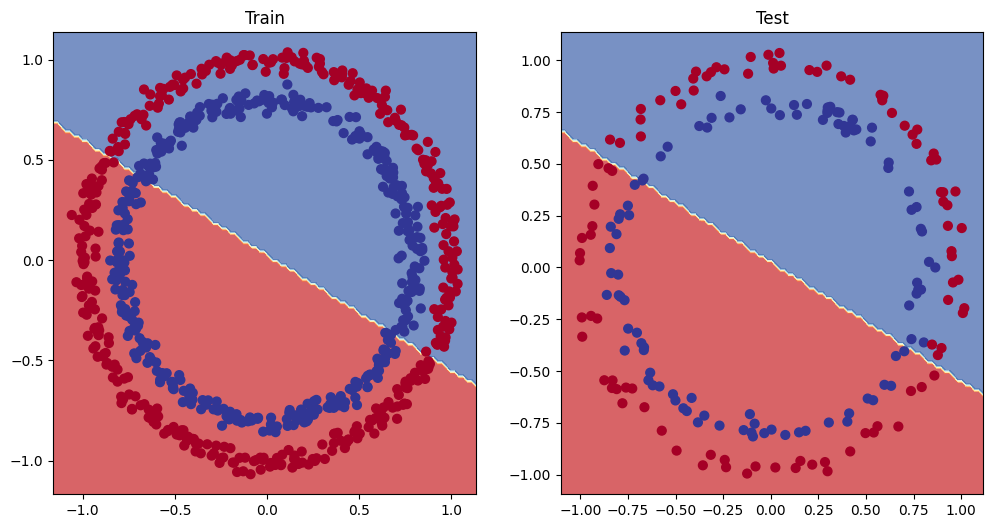

In [27]:
# Plot decision boundaries for training and test sets
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_0, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_0, X_test, y_test)

OKay, this looks like it's trying to fit a straight line. Let's see yhow we can improve this

## 5. Improving a model (from a model perspective)

Let's try to fix our model's underfitting problem.

Focusing specifically on the model (not the data), there are a few ways we could do this.

| Model improvement technique* | What does it do? |
| ----- | ----- |
| **Add more layers** | Each layer *potentially* increases the learning capabilities of the model with each layer being able to learn some kind of new pattern in the data. More layers are often referred to as making your neural network *deeper*. |
| **Add more hidden units** | Similar to the above, more hidden units per layer means a *potential* increase in learning capabilities of the model. More hidden units are often referred to as making your neural network *wider*. |
| **Fitting for longer (more epochs)** | Your model might learn more if it had more opportunities to look at the data. |
| **Changing the activation functions** | Some data just can't be fit with only straight lines (like what we've seen), using non-linear activation functions can help with this (hint, hint). |
| **Change the learning rate** | Less model specific, but still related, the learning rate of the optimizer decides how much a model should change its parameters each step, too much and the model overcorrects, too little and it doesn't learn enough. |
| **Change the loss function** | Again, less model specific but still important, different problems require different loss functions. For example, a binary cross entropy loss function won't work with a multi-class classification problem. |
| **Use transfer learning** | Take a pretrained model from a problem domain similar to yours and adjust it to your own problem. We cover transfer learning in [notebook 06](https://www.learnpytorch.io/06_pytorch_transfer_learning/). |

> **Note:** *because you can adjust all of these by hand, they're referred to as **hyperparameters**.
>
> And this is also where machine learning's half art half science comes in, there's no real way to know here what the best combination of values is for your project, best to follow the data scientist's motto of "experiment, experiment, experiment".

Let's see what happens if we add an extra layer to our model, fit for longer (`epochs=1000` instead of `epochs=100`) and increase the number of hidden units from `5` to `10`.

We'll follow the same steps we did above but with a few changed hyperparameters.

In [28]:
class CircleModelV1(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_1 = nn.Linear(in_features=2, out_features=10)
        self.layer_2 = nn.Linear(in_features=10, out_features=10) # extra layer
        self.layer_3 = nn.Linear(in_features=10, out_features=1)

    def forward(self, x): # note: always make sure forward is spelt correctly!
        # Creating a model like this is the same as below, though below
        # generally benefits from speedups where possible.
        # z = self.layer_1(x)
        # z = self.layer_2(z)
        # z = self.layer_3(z)
        # return z
        return self.layer_3(self.layer_2(self.layer_1(x)))

model_1 = CircleModelV1().to(device)
model_1

CircleModelV1(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
)

In [29]:
# loss_fn = nn.BCELoss() # Requires sigmoid on input
loss_fn = nn.BCEWithLogitsLoss() # Does not require sigmoid on input
optimizer = torch.optim.SGD(model_1.parameters(), lr=0.1)

In [30]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

# Set the number of epochs
epochs = 1000 # Train for longer

# Put data to target device
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

for epoch in range(epochs):
    ### Training
    # 1. Forward pass
    y_logits = model_1(X_train).squeeze()
    y_pred = torch.round(torch.sigmoid(y_logits)) # logits -> prediction probabilities -> prediction labels

    # 2. Calculate loss/accuracy
    loss = loss_fn(y_logits, y_train)
    acc = accuracy_fn(y_true=y_train,
                      y_pred=y_pred)

    # 3. Optimizer zero grad
    optimizer.zero_grad()

    # 4. Loss backwards
    loss.backward()

    # 5. Optimizer step
    optimizer.step()

    ### Testing
    model_1.eval()
    with torch.inference_mode():
        # 1. Forward pass
        test_logits = model_1(X_test).squeeze()
        test_pred = torch.round(torch.sigmoid(test_logits))
        # 2. Caculate loss/accuracy
        test_loss = loss_fn(test_logits,
                            y_test)
        test_acc = accuracy_fn(y_true=y_test,
                               y_pred=test_pred)

    # Print out what's happening every 10 epochs
    if epoch % 100 == 0:
        print(f"Epoch: {epoch} | Loss: {loss:.5f}, Accuracy: {acc:.2f}% | Test loss: {test_loss:.5f}, Test acc: {test_acc:.2f}%")


Epoch: 0 | Loss: 0.69396, Accuracy: 50.88% | Test loss: 0.69261, Test acc: 51.00%
Epoch: 100 | Loss: 0.69305, Accuracy: 50.38% | Test loss: 0.69379, Test acc: 48.00%
Epoch: 200 | Loss: 0.69299, Accuracy: 51.12% | Test loss: 0.69437, Test acc: 46.00%
Epoch: 300 | Loss: 0.69298, Accuracy: 51.62% | Test loss: 0.69458, Test acc: 45.00%
Epoch: 400 | Loss: 0.69298, Accuracy: 51.12% | Test loss: 0.69465, Test acc: 46.00%
Epoch: 500 | Loss: 0.69298, Accuracy: 51.00% | Test loss: 0.69467, Test acc: 46.00%
Epoch: 600 | Loss: 0.69298, Accuracy: 51.00% | Test loss: 0.69468, Test acc: 46.00%
Epoch: 700 | Loss: 0.69298, Accuracy: 51.00% | Test loss: 0.69468, Test acc: 46.00%
Epoch: 800 | Loss: 0.69298, Accuracy: 51.00% | Test loss: 0.69468, Test acc: 46.00%
Epoch: 900 | Loss: 0.69298, Accuracy: 51.00% | Test loss: 0.69468, Test acc: 46.00%


Still pretty bad. Let's look at the decision boundary again

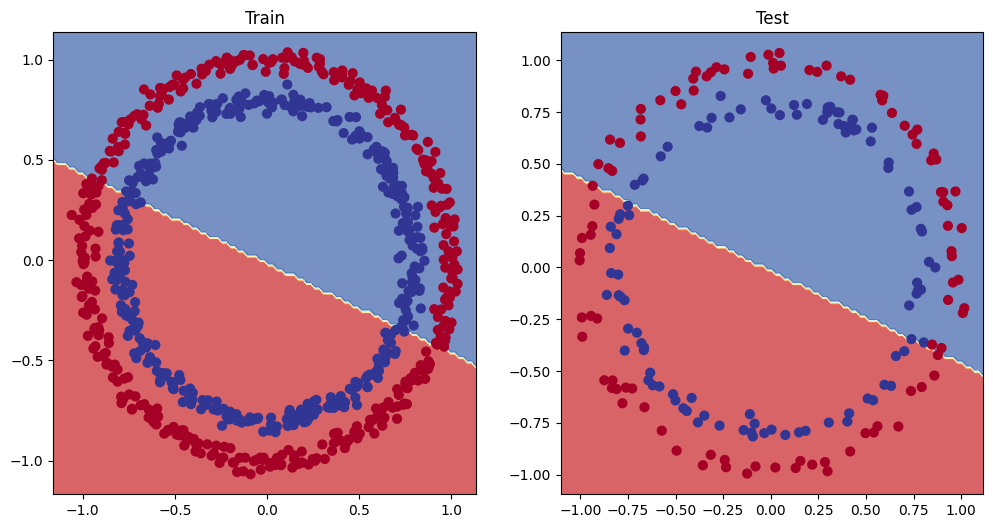

In [31]:
# Plot decision boundaries for training and test sets
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_1, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_1, X_test, y_test)

The problem might be that this model has no non-linearity and therefore can only work with linear data. Let's check that assumption

### Check if this model works with linear data

In [63]:
# Make some linear data

weight = 0.7
bias = 0.3
start = 0
end = 2
step = 0.01

X_linear = torch.arange(start, end, step).unsqueeze(dim=1)
y_linear = weight * X_linear + bias

X_linear.shape, y_linear.shape # we might need to unsqueeze X at some point

(torch.Size([200, 1]), torch.Size([200, 1]))

In [64]:
# Split into train and test sets

Xlin_train, Xlin_test, ylin_train, ylin_test = train_test_split(X_linear,
                                                                  y_linear,
                                                                  test_size=0.2,
                                                                  random_state=42)

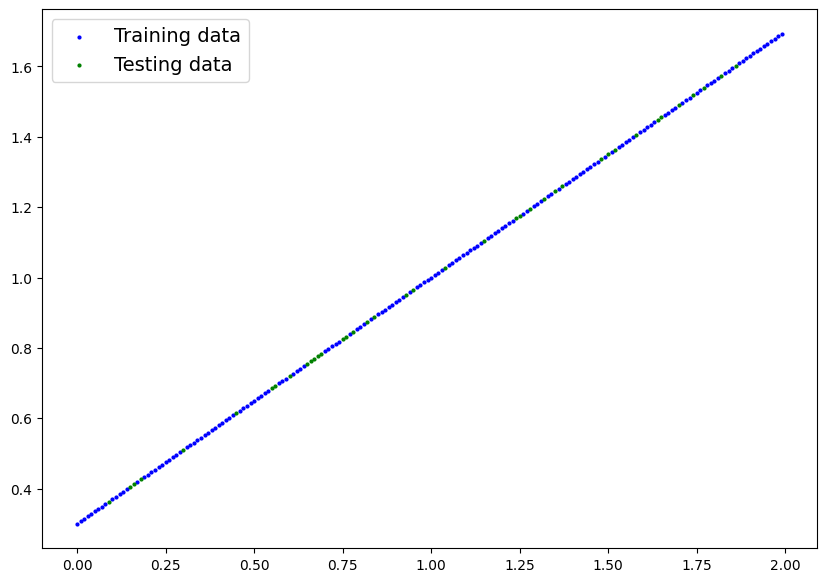

In [65]:
# Let's visualize the data we have

plot_predictions(train_data=Xlin_train,
                 train_labels=ylin_train,
                 test_data=Xlin_test,
                 test_labels=ylin_test)

Thsi works let's train the model on this data

Let's stick with the same loss function and optimizer and see what happens

In [66]:
# create a training and testing loop for this Xlin data

torch.manual_seed(42)
torch.cuda.manual_seed(42)

epochs = 1000

# put data into target device
Xlin_train, ylin_train = Xlin_train.to(device), ylin_train.to(device)
Xlin_test, ylin_test = Xlin_test.to(device), ylin_test.to(device)
model_1.to(device)

for epoch in range(epochs):
  # forward pass
  model_1.train()
  y_logits = model_1(Xlin_train).squeeze()
  y_pred = torch.round(torch.sigmoid(y_logits))


RuntimeError: mat1 and mat2 shapes cannot be multiplied (160x1 and 2x10)

Will not work because teh circle model has two inputs (X1, X2) per data - whereas here, there's only one. We need a new model

In [67]:
# create a new model for linear data

model_lin = nn.Sequential(
    nn.Linear(in_features=1, out_features=10),
    nn.Linear(in_features=10, out_features=10),
    nn.Linear(in_features=10, out_features=1)
).to(device)

model_lin

Sequential(
  (0): Linear(in_features=1, out_features=10, bias=True)
  (1): Linear(in_features=10, out_features=10, bias=True)
  (2): Linear(in_features=10, out_features=1, bias=True)
)

In [71]:
# create a training and testing loop for this Xlin data

torch.manual_seed(42)
torch.cuda.manual_seed(42)

epochs = 1000

# put data into target device
Xlin_train, ylin_train = Xlin_train.to(device), ylin_train.to(device)
Xlin_test, ylin_test = Xlin_test.to(device), ylin_test.to(device)

for epoch in range(epochs):
  # forward pass
  model_lin.train()
  y_logits = model_lin(Xlin_train)
  y_pred = torch.round(torch.sigmoid(y_logits))

  # calculate loss
  loss = loss_fn(y_logits, ylin_train)

  # optimizer zero grad
  optimizer.zero_grad()

  # loss backwards
  loss.backward()

  # optimizer step
  optimizer.step()

  ## Testing
  model_lin.eval()
  with torch.inference_mode():
    # forward pass
    test_logits = model_lin(Xlin_test)
    test_pred = torch.round(torch.sigmoid(test_logits))

    # loss and acc
    test_loss = loss_fn(test_logits, ylin_test)

  ## Print out what's happening
  if epoch % 100 == 0:
    print(f"Epoch: {epoch} | Loss: {loss:.5f} | Test loss: {test_loss:.5f}")

Epoch: 0 | Loss: 0.61975 | Test loss: 0.63396
Epoch: 100 | Loss: 0.61975 | Test loss: 0.63396
Epoch: 200 | Loss: 0.61975 | Test loss: 0.63396
Epoch: 300 | Loss: 0.61975 | Test loss: 0.63396
Epoch: 400 | Loss: 0.61975 | Test loss: 0.63396
Epoch: 500 | Loss: 0.61975 | Test loss: 0.63396
Epoch: 600 | Loss: 0.61975 | Test loss: 0.63396
Epoch: 700 | Loss: 0.61975 | Test loss: 0.63396
Epoch: 800 | Loss: 0.61975 | Test loss: 0.63396
Epoch: 900 | Loss: 0.61975 | Test loss: 0.63396


Maybe we need a new loss function - suited for linear data

In [72]:
# Loss function suited for linear data
loss_fn = nn.MSELoss()
optimizer = torch.optim.SGD(model_lin.parameters(), lr=0.1)

In [73]:
# Do the training loop again


torch.manual_seed(42)
torch.cuda.manual_seed(42)

epochs = 1000

# put data into target device
Xlin_train, ylin_train = Xlin_train.to(device), ylin_train.to(device)
Xlin_test, ylin_test = Xlin_test.to(device), ylin_test.to(device)

for epoch in range(epochs):
  # forward pass
  model_lin.train()
  y_logits = model_lin(Xlin_train)
  y_pred = torch.round(torch.sigmoid(y_logits))

  # calculate loss
  loss = loss_fn(y_logits, ylin_train)

  # optimizer zero grad
  optimizer.zero_grad()

  # loss backwards
  loss.backward()

  # optimizer step
  optimizer.step()

  ## Testing
  model_lin.eval()
  with torch.inference_mode():
    # forward pass
    test_logits = model_lin(Xlin_test)
    test_pred = torch.round(torch.sigmoid(test_logits))

    # loss and acc
    test_loss = loss_fn(test_logits, ylin_test)

  ## Print out what's happening
  if epoch % 100 == 0:
    print(f"Epoch: {epoch} | Loss: {loss:.5f} | Test loss: {test_loss:.5f}")

Epoch: 0 | Loss: 1.03514 | Test loss: 0.13821
Epoch: 100 | Loss: 0.00000 | Test loss: 0.00000
Epoch: 200 | Loss: 0.00000 | Test loss: 0.00000
Epoch: 300 | Loss: 0.00000 | Test loss: 0.00000
Epoch: 400 | Loss: 0.00000 | Test loss: 0.00000
Epoch: 500 | Loss: 0.00000 | Test loss: 0.00000
Epoch: 600 | Loss: 0.00000 | Test loss: 0.00000
Epoch: 700 | Loss: 0.00000 | Test loss: 0.00000
Epoch: 800 | Loss: 0.00000 | Test loss: 0.00000
Epoch: 900 | Loss: 0.00000 | Test loss: 0.00000


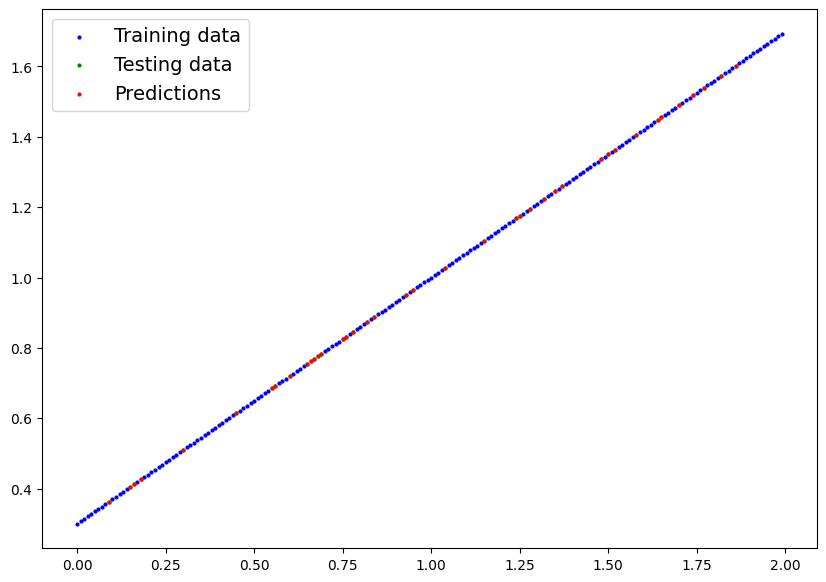

In [75]:
# Okay let's visualize the preds

model_lin.eval()
with torch.inference_mode():
  y_preds = model_lin(Xlin_test)

# Plot data and preds - have to transfter data to cpu because matplotlib can't handle data on GPU

plot_predictions(train_data=Xlin_train.cpu(),
                 train_labels=ylin_train.cpu(),
                 test_data=Xlin_test.cpu(),
                 test_labels=ylin_test.cpu(),
                 predictions=y_preds.cpu())

As we can see, this model is excellent on linear data. What we need in the model is non-linearity!

## 6. Adding Non-linearity to the model

The way we do this in the circle model is to add ReLU layers between hidden layers

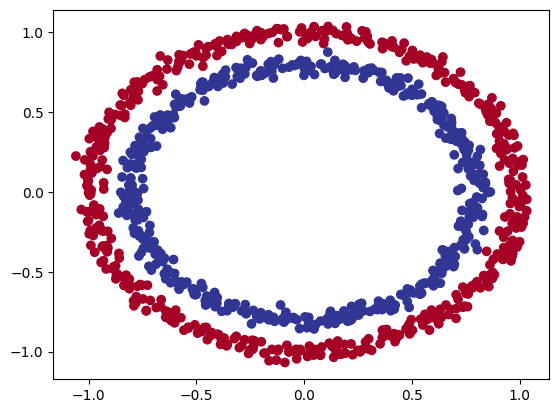

In [80]:
# Let's look at our data again

plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdYlBu)

In [81]:
print(f'Shapes of X_train: {X_train.shape}, y_train: {y_train.shape}')
print(f'Shapes of X_test: {X_test.shape}, y_test: {y_test.shape}')

Shapes of X_train: torch.Size([800, 2]), y_train: torch.Size([800])
Shapes of X_test: torch.Size([200, 2]), y_test: torch.Size([200])


This all loooks good. Let's build our model

In [82]:
class CircleModelV2(nn.Module):
    def __init__(self):
        super().__init__()

        self.layer_1 = nn.Linear(in_features=2, out_features=10)
        self.layer_2 = nn.Linear(in_features=10, out_features=10)
        self.layer_3 = nn.Linear(in_features=10, out_features=1)
        self.relu = nn.ReLU()

    def forward(self, x):
        return self.layer_3(self.relu(self.layer_2(self.relu(self.layer_1(x)))))

model_2 = CircleModelV2().to(device)
model_2

CircleModelV2(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
  (relu): ReLU()
)

In [83]:
# Setup loss and optimizer
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(model_2.parameters(), lr=0.1)

In [85]:
# Train the model

torch.manual_seed(42)
torch.cuda.manual_seed(42)

epochs = 1000

# Put all data to target device
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

for epoch in range(epochs):
    ### Training
    model_2.train()

    # 1. Forward pass (model outputs raw logits)
    y_logits = model_2(X_train).squeeze()
    y_pred = torch.round(torch.sigmoid(y_logits))

    # 2. Calculate loss and acc
    loss = loss_fn(y_logits, y_train)
    acc = accuracy_fn(y_train, y_pred)

    # 3. Optimizer zero grad
    optimizer.zero_grad()

    # 4. Loss backwards
    loss.backward()

    # 5. Optimizer step
    optimizer.step()

    ### Testing
    model_2.eval()
    with torch.inference_mode():
        # 1. Forward pass
        test_logits = model_2(X_test).squeeze()
        test_pred = torch.round(torch.sigmoid(test_logits))

        # 2. Loss and acc
        test_loss = loss_fn(test_logits, y_test)
        test_acc = accuracy_fn(y_true=y_test, y_pred=test_pred)

    ### Print out what's happening every 100 epochs
    if epoch % 100 == 0:
        print(f"Epoch: {epoch} | Loss: {loss:.5f}, Accuracy: {acc:.2f}% | Test loss: {test_loss:.5f}, Test acc: {test_acc:.2f}%")


Epoch: 0 | Loss: 0.56818, Accuracy: 87.75% | Test loss: 0.57378, Test acc: 86.50%
Epoch: 100 | Loss: 0.48153, Accuracy: 93.50% | Test loss: 0.49935, Test acc: 90.50%
Epoch: 200 | Loss: 0.37056, Accuracy: 97.75% | Test loss: 0.40595, Test acc: 92.00%
Epoch: 300 | Loss: 0.25458, Accuracy: 99.00% | Test loss: 0.30333, Test acc: 96.50%
Epoch: 400 | Loss: 0.17180, Accuracy: 99.50% | Test loss: 0.22108, Test acc: 97.50%
Epoch: 500 | Loss: 0.12188, Accuracy: 99.62% | Test loss: 0.16512, Test acc: 99.00%
Epoch: 600 | Loss: 0.09123, Accuracy: 99.88% | Test loss: 0.12741, Test acc: 99.50%
Epoch: 700 | Loss: 0.07100, Accuracy: 99.88% | Test loss: 0.10319, Test acc: 99.50%
Epoch: 800 | Loss: 0.05773, Accuracy: 99.88% | Test loss: 0.08672, Test acc: 99.50%
Epoch: 900 | Loss: 0.04853, Accuracy: 99.88% | Test loss: 0.07474, Test acc: 99.50%


I ran the above code twice (2000 epochs) and this is great!

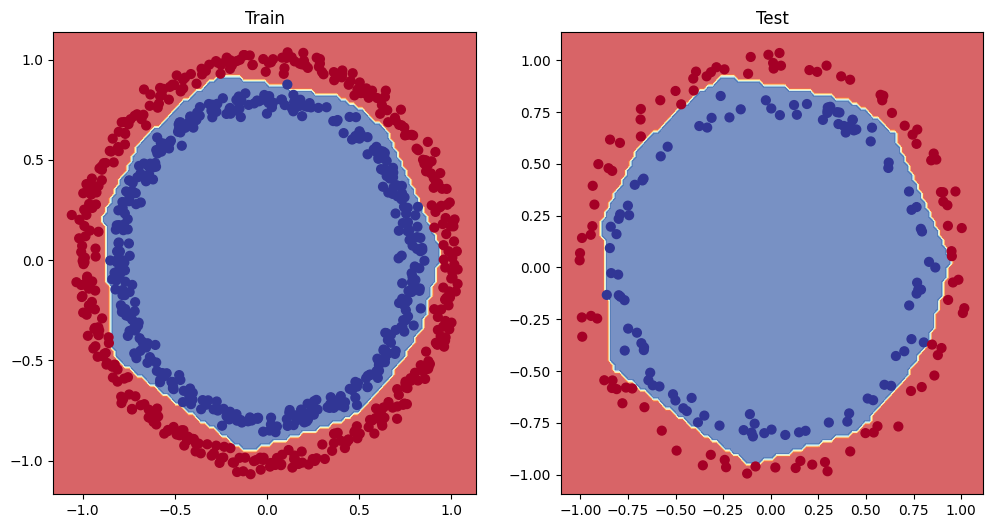

In [86]:
# Make predictions
model_2.eval()
with torch.inference_mode():
    y_logits = model_2(X_test).squeeze()
    y_pred = torch.round(torch.sigmoid(y_logits))

# PLot the decision boundary
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_2, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_2, X_test, y_test)
plt.show()